In [150]:
import pandas as pd

train_df = pd.read_csv('listings_train.csv')
test_df = pd.read_csv('listings_test_features.csv')

# EDA

In [151]:
# To answer questions in assignment4 pdf
train_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 42234 entries, 0 to 42233
Data columns (total 36 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   id                              42234 non-null  int64  
 1   name                            42234 non-null  str    
 2   host_id                         42234 non-null  int64  
 3   host_name                       42216 non-null  str    
 4   host_total_listings_count       42218 non-null  float64
 5   host_has_profile_pic            42218 non-null  str    
 6   host_identity_verified          42218 non-null  str    
 7   neighbourhood_group             0 non-null      float64
 8   neighbourhood                   42234 non-null  str    
 9   latitude                        42234 non-null  float64
 10  longitude                       42234 non-null  float64
 11  room_type                       42234 non-null  str    
 12  minimum_nights                  42234 non-n

In [152]:
test_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 8199 entries, 0 to 8198
Data columns (total 35 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   id                              8199 non-null   int64  
 1   name                            8199 non-null   str    
 2   host_id                         8199 non-null   int64  
 3   host_name                       8199 non-null   str    
 4   host_total_listings_count       8199 non-null   float64
 5   host_has_profile_pic            8199 non-null   str    
 6   host_identity_verified          8199 non-null   str    
 7   neighbourhood_group             0 non-null      float64
 8   neighbourhood                   8199 non-null   str    
 9   latitude                        8199 non-null   float64
 10  longitude                       8199 non-null   float64
 11  room_type                       8199 non-null   str    
 12  minimum_nights                  8199 non-null

In [153]:
train_df['price'].describe()

count    42234.000000
mean       166.242743
std         98.380093
min         50.000000
25%         90.000000
50%        141.000000
75%        215.000000
max        500.000000
Name: price, dtype: float64

In [154]:
#answer to question 2
train_df['price'].median()

np.float64(141.0)

array([[<Axes: title={'center': 'id'}>,
        <Axes: title={'center': 'host_id'}>,
        <Axes: title={'center': 'host_total_listings_count'}>,
        <Axes: title={'center': 'neighbourhood_group'}>,
        <Axes: title={'center': 'latitude'}>],
       [<Axes: title={'center': 'longitude'}>,
        <Axes: title={'center': 'minimum_nights'}>,
        <Axes: title={'center': 'calculated_host_listings_count'}>,
        <Axes: title={'center': 'availability_365'}>,
        <Axes: title={'center': 'number_of_reviews_ltm'}>],
       [<Axes: title={'center': 'accommodates'}>,
        <Axes: title={'center': 'bathrooms'}>,
        <Axes: title={'center': 'bedrooms'}>,
        <Axes: title={'center': 'beds'}>,
        <Axes: title={'center': 'availability_30'}>],
       [<Axes: title={'center': 'availability_60'}>,
        <Axes: title={'center': 'availability_90'}>,
        <Axes: title={'center': 'number_of_reviews'}>,
        <Axes: title={'center': 'reviews_per_month'}>,
        <Axe

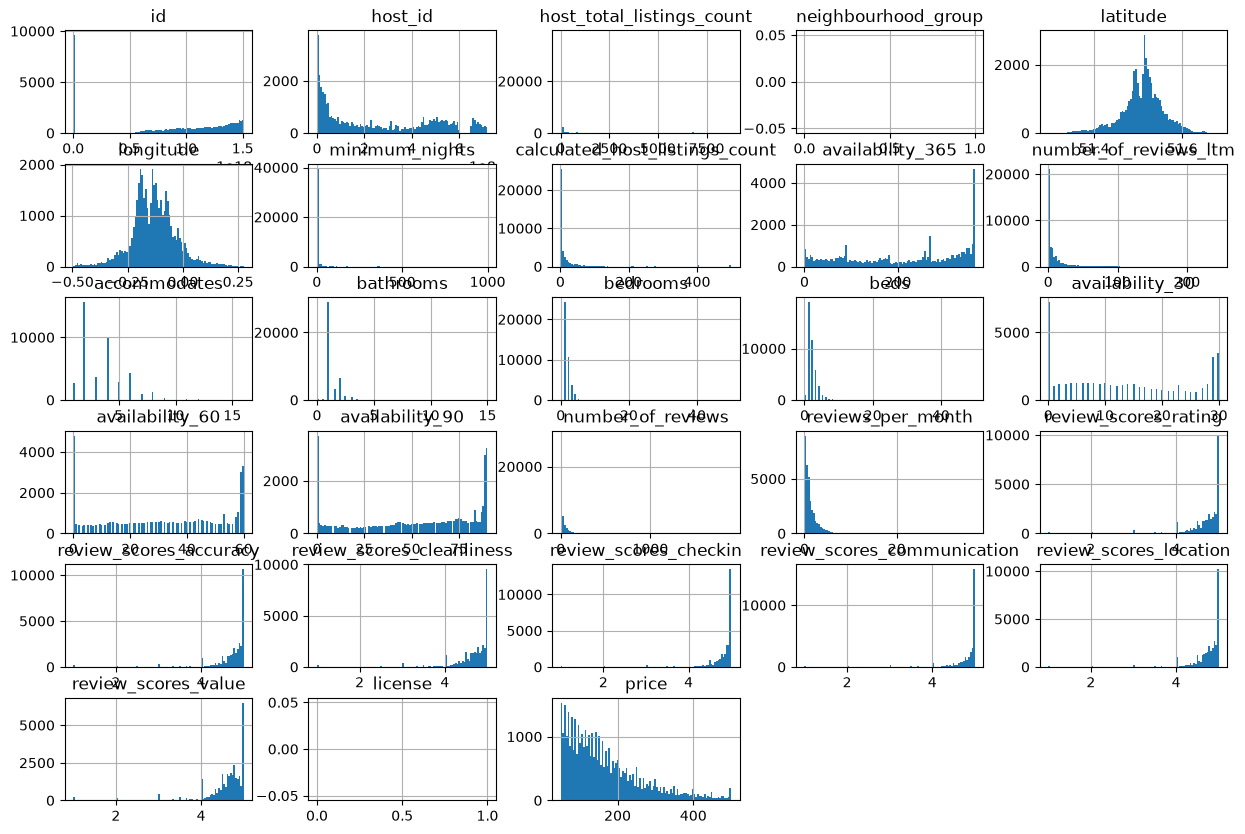

In [155]:
train_df.hist(bins=100, figsize=(15,10))

In [156]:
for col in train_df.columns:
    print('--------')
    print(train_df[col].value_counts(dropna=False))

--------
id
863718884129314541     1
1246272787951735423    1
995836785136017274     1
888497692875319566     1
1069328087003020991    1
                      ..
52667545               1
1424101240983641464    1
1328874387841665633    1
2576995                1
750547105050926406     1
Name: count, Length: 42234, dtype: int64
--------
name
Flat in London                                       14
Standard Single Room                                 12
Letzi Ensuite Room | 10 Mins Wembley | Fast WiFi     11
Seven Dials Hotel, Covent Garden, Single en suite    11
Private Double Room in Warren Street                 11
                                                     ..
Lovely bedroom in a large flat                        1
River view 2 bedroom flat                             1
Charming West London Mews House                       1
Dbl Room, W'stow Central 2 mins                       1
Double room @ Hackney, near Victoria Park London      1
Name: count, Length: 41118, dtype: int64
-

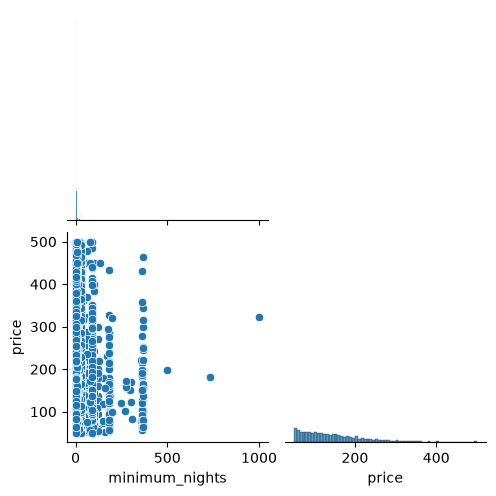

In [157]:
import seaborn as sns
sns.pairplot(train_df[['minimum_nights', 'price']], corner=True)

<Axes: xlabel='minimum_nights', ylabel='price'>

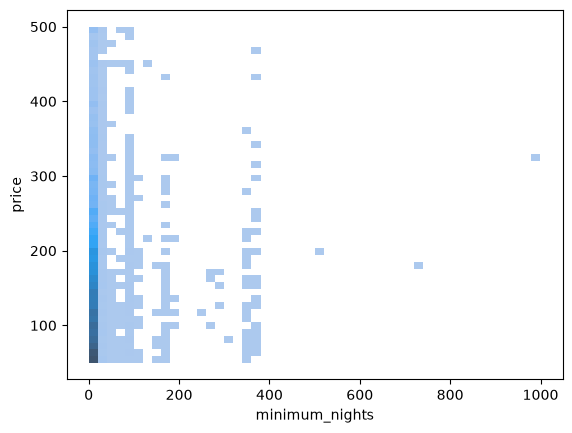

In [158]:
sns.histplot(bins=50, x=train_df['minimum_nights'], y=train_df['price'])

# Data Cleansing/ Feature Engineering

In [159]:
train_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 42234 entries, 0 to 42233
Data columns (total 36 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   id                              42234 non-null  int64  
 1   name                            42234 non-null  str    
 2   host_id                         42234 non-null  int64  
 3   host_name                       42216 non-null  str    
 4   host_total_listings_count       42218 non-null  float64
 5   host_has_profile_pic            42218 non-null  str    
 6   host_identity_verified          42218 non-null  str    
 7   neighbourhood_group             0 non-null      float64
 8   neighbourhood                   42234 non-null  str    
 9   latitude                        42234 non-null  float64
 10  longitude                       42234 non-null  float64
 11  room_type                       42234 non-null  str    
 12  minimum_nights                  42234 non-n

In [160]:
#removing totally null columns and string columns except for neighborhood
train_df.drop(['id', 'name', 'host_name', 'host_has_profile_pic', 'host_identity_verified', 'neighbourhood_group', 'room_type', 'amenities', 'last_review', 'license'], axis=1, inplace=True)
train_df

,host_id,host_total_listings_count,neighbourhood,latitude,longitude,minimum_nights,calculated_host_listings_count,availability_365,number_of_reviews_ltm,accommodates,...,number_of_reviews,reviews_per_month,review_scores_rating,review_scores_accuracy,review_scores_cleanliness,review_scores_checkin,review_scores_communication,review_scores_location,review_scores_value,price
0,508846510,1.0,Hammersmith and Fulham,51.473060,-0.183720,2,1,1,6,2,...,31,1.06,4.71,4.71,4.58,4.65,4.87,4.77,4.65,104.0
1,229912595,23.0,Lambeth,51.461770,-0.121320,28,15,319,3,4,...,3,0.32,5.00,5.00,5.00,5.00,5.00,5.00,5.00,219.0
2,491436321,26.0,Hackney,51.545587,-0.058349,1,25,365,4,3,...,4,0.86,4.00,4.25,4.00,4.25,4.50,4.00,4.00,96.0
3,513462549,4.0,Kensington and Chelsea,51.492899,-0.195460,1,4,270,0,1,...,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,200.0
4,1432477,791.0,Tower Hamlets,51.498470,-0.013030,1,252,354,6,4,...,17,0.87,4.82,4.82,5.00,4.65,4.88,4.88,4.82,261.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
42229,205722011,3.0,Lambeth,51.460710,-0.109460,2,3,89,1,2,...,3,0.07,4.67,4.33,4.33,4.00,4.67,5.00,4.00,82.0
42230,696260456,1.0,Tower Hamlets,51.490970,-0.023260,1,1,180,0,4,...,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,149.0
42231,10468628,4.0,Hammersmith and Fulham,51.488560,-0.205160,2,2,314,9,6,...,9,1.91,5.00,5.00,4.33,5.00,5.00,4.67,4.67,416.0
42232,8220928,1.0,Waltham Forest,51.582153,-0.018711,1,1,143,3,2,...,3,3.00,5.00,5.00,5.00,4.67,5.00,5.00,5.00,50.0


In [161]:
#neighborhood has no Nan values
for col in train_df.select_dtypes(include="number").columns:
    train_df[col] = train_df[col].fillna(train_df[col].median())

In [162]:
#one-hot encoding neighborhood
#Parts taken from Ryan and Matt Datascience YT tutorial on sklearn onehot encoder
from sklearn.preprocessing import OneHotEncoder
ohe = OneHotEncoder(handle_unknown='ignore', sparse_output=False).set_output(transform='pandas')


In [163]:
ohetransform = ohe.fit_transform(train_df[['neighbourhood']])
ohetransform.info()

<class 'pandas.DataFrame'>
RangeIndex: 42234 entries, 0 to 42233
Data columns (total 33 columns):
 #   Column                                Non-Null Count  Dtype  
---  ------                                --------------  -----  
 0   neighbourhood_Barking and Dagenham    42234 non-null  float64
 1   neighbourhood_Barnet                  42234 non-null  float64
 2   neighbourhood_Bexley                  42234 non-null  float64
 3   neighbourhood_Brent                   42234 non-null  float64
 4   neighbourhood_Bromley                 42234 non-null  float64
 5   neighbourhood_Camden                  42234 non-null  float64
 6   neighbourhood_City of London          42234 non-null  float64
 7   neighbourhood_Croydon                 42234 non-null  float64
 8   neighbourhood_Ealing                  42234 non-null  float64
 9   neighbourhood_Enfield                 42234 non-null  float64
 10  neighbourhood_Greenwich               42234 non-null  float64
 11  neighbourhood_Hackney     

In [164]:
ohetransform.columns = ohetransform.columns.str.removeprefix("neighbourhood_")
ohetransform.info()

<class 'pandas.DataFrame'>
RangeIndex: 42234 entries, 0 to 42233
Data columns (total 33 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Barking and Dagenham    42234 non-null  float64
 1   Barnet                  42234 non-null  float64
 2   Bexley                  42234 non-null  float64
 3   Brent                   42234 non-null  float64
 4   Bromley                 42234 non-null  float64
 5   Camden                  42234 non-null  float64
 6   City of London          42234 non-null  float64
 7   Croydon                 42234 non-null  float64
 8   Ealing                  42234 non-null  float64
 9   Enfield                 42234 non-null  float64
 10  Greenwich               42234 non-null  float64
 11  Hackney                 42234 non-null  float64
 12  Hammersmith and Fulham  42234 non-null  float64
 13  Haringey                42234 non-null  float64
 14  Harrow                  42234 non-null  float64
 

In [165]:
train_df = pd.concat([train_df,ohetransform], axis=1).drop(columns='neighbourhood')
train_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 42234 entries, 0 to 42233
Data columns (total 58 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   host_id                         42234 non-null  int64  
 1   host_total_listings_count       42234 non-null  float64
 2   latitude                        42234 non-null  float64
 3   longitude                       42234 non-null  float64
 4   minimum_nights                  42234 non-null  int64  
 5   calculated_host_listings_count  42234 non-null  int64  
 6   availability_365                42234 non-null  int64  
 7   number_of_reviews_ltm           42234 non-null  int64  
 8   accommodates                    42234 non-null  int64  
 9   bathrooms                       42234 non-null  float64
 10  bedrooms                        42234 non-null  float64
 11  beds                            42234 non-null  float64
 12  availability_30                 42234 non-n

# Model Preparation

In [166]:
#encoding our test_df the same way we encoded our train_df
ohetransform = ohe.fit_transform(test_df[['neighbourhood']])
ohetransform.columns = ohetransform.columns.str.removeprefix("neighbourhood_")
ohetransform.info()

<class 'pandas.DataFrame'>
RangeIndex: 8199 entries, 0 to 8198
Data columns (total 33 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Barking and Dagenham    8199 non-null   float64
 1   Barnet                  8199 non-null   float64
 2   Bexley                  8199 non-null   float64
 3   Brent                   8199 non-null   float64
 4   Bromley                 8199 non-null   float64
 5   Camden                  8199 non-null   float64
 6   City of London          8199 non-null   float64
 7   Croydon                 8199 non-null   float64
 8   Ealing                  8199 non-null   float64
 9   Enfield                 8199 non-null   float64
 10  Greenwich               8199 non-null   float64
 11  Hackney                 8199 non-null   float64
 12  Hammersmith and Fulham  8199 non-null   float64
 13  Haringey                8199 non-null   float64
 14  Harrow                  8199 non-null   float64
 15

In [167]:
test_df = pd.concat([test_df,ohetransform], axis=1).drop(columns='neighbourhood')

In [168]:
from sklearn.model_selection import train_test_split
#taken from our in class practical sep 11
#our Y target(s): airbnb 'price'
#our X or our Data without the Target Data
train_x, test_x, train_y, test_y = train_test_split(train_df.drop(['price'], axis=1, inplace=False), 
                 train_df.price,
                 test_size=0.2)

In [170]:
from sklearn.preprocessing import StandardScaler

ss = StandardScaler()
ss.fit(train_x)
train_x = ss.transform(train_x)
test_x = ss.transform(test_x)

# Model

In [171]:
from sklearn.linear_model import LinearRegression
reg = LinearRegression()
reg.fit(train_x,train_y)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](57,)","[-2.9 , 1.07,-1.14,...,-7.92, 0.69,19.69]"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,166.3
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,57
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(56)
"singular_ singular_: array of shape (min(X, y),)Singular values of `X`. Only available when `X` is dense.","ndarray[float64](57,)","[434.2 ,339.36,316.2 ,..., 31.19, 22.78, 0. ]"


In [174]:
hyp = reg.predict(test_df)
hyp

c:\Users\joano\Documents\School\CS463\Sept\.venv\Lib\site-packages\sklearn\utils\validation.py:2823: UserWarning: X has feature names, but LinearRegression was fitted without feature names
  warnings.warn(


ValueError: could not convert string to float: 'chill flat'